Task1: Visualize distribution (e.g. Bar or Pie charts) of the heart attack dataset

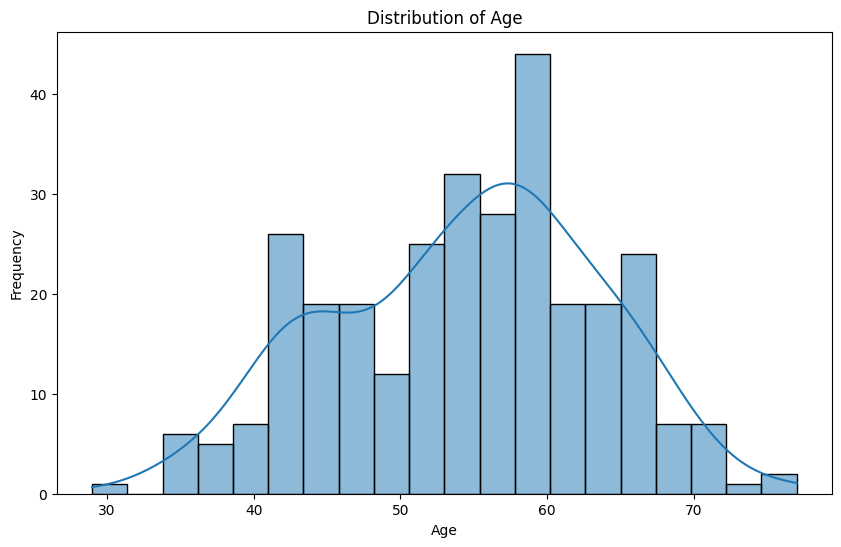

C:\Users\dell\AppData\Local\Temp\ipykernel_23460\3721793123.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_counts = data.groupby('age_group')['output'].value_counts().unstack().fillna(0)


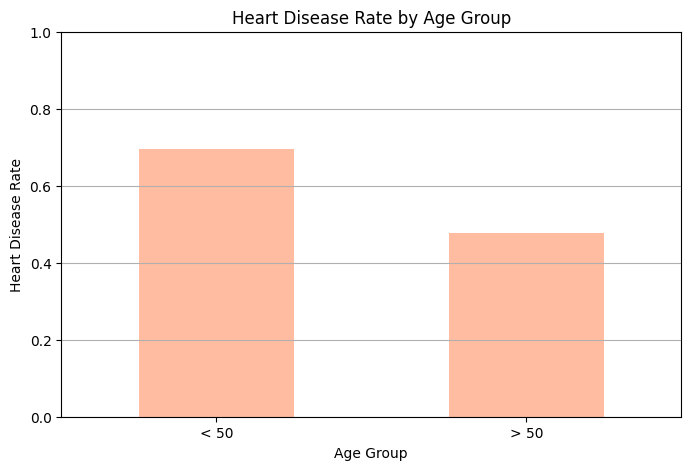

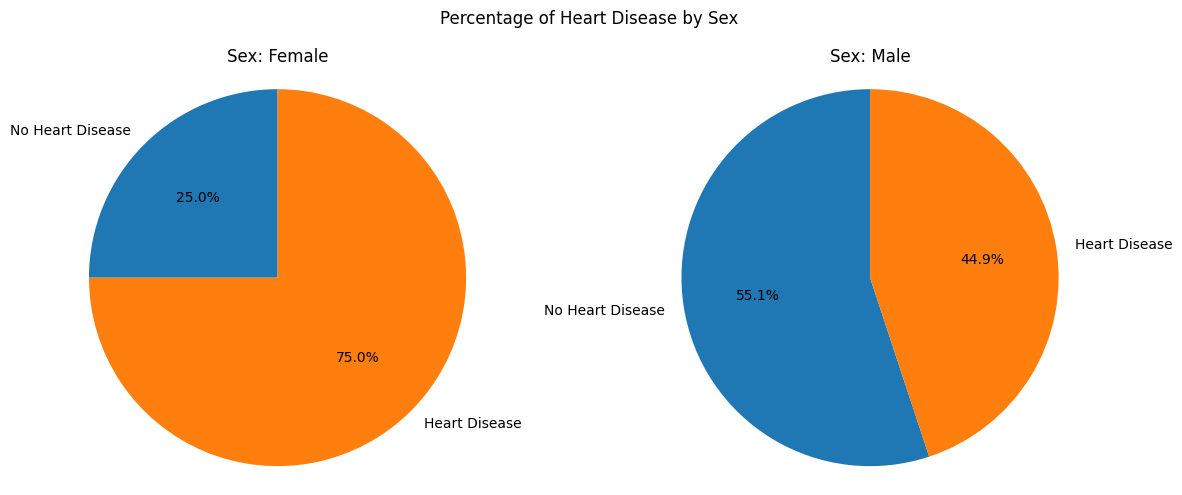

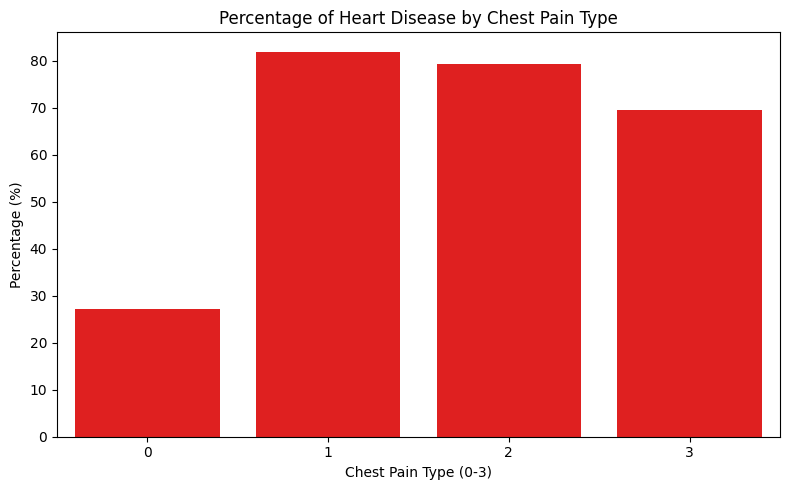

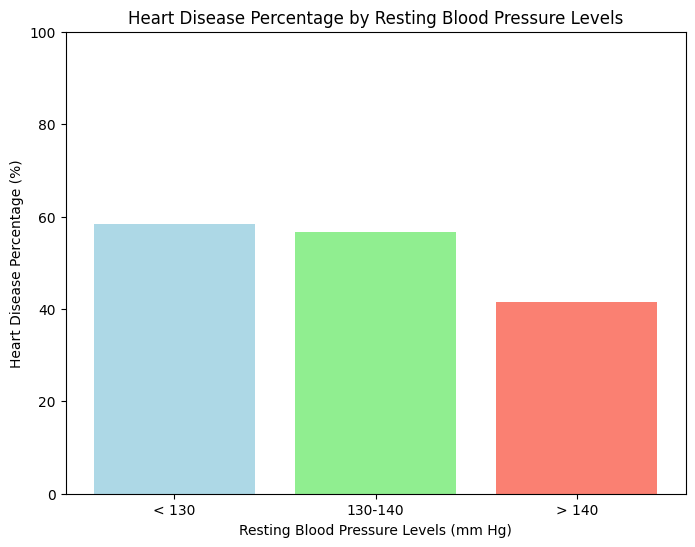

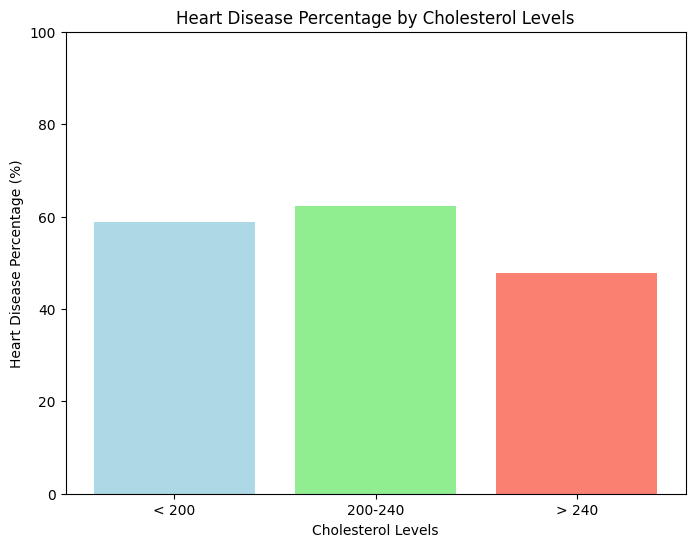

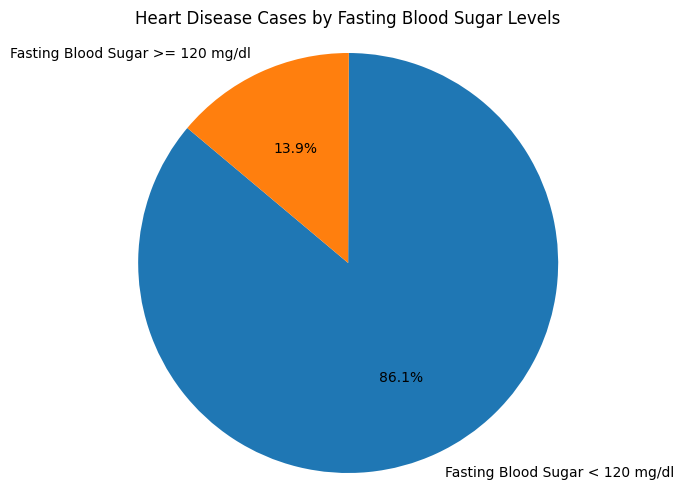

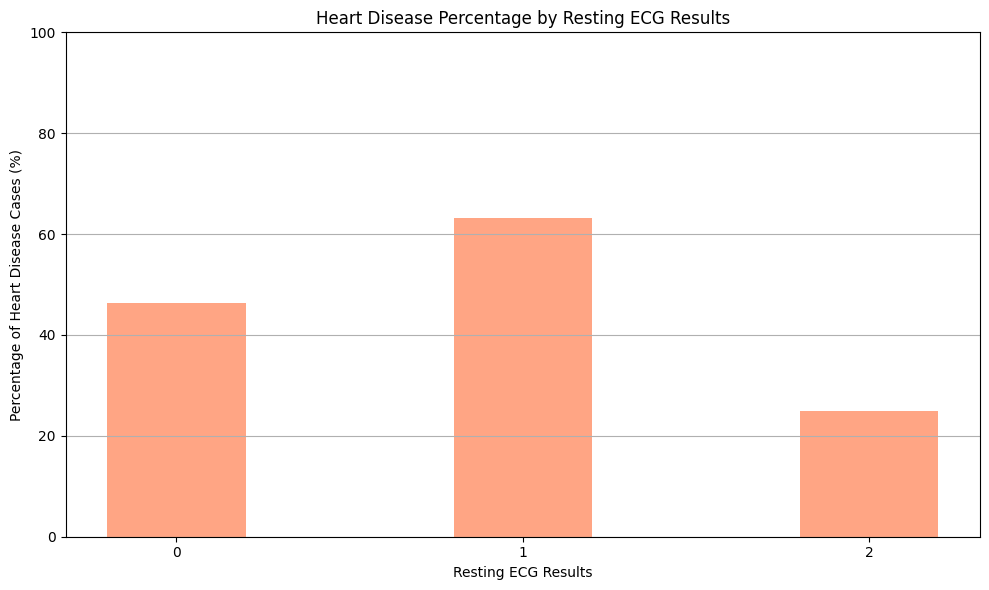

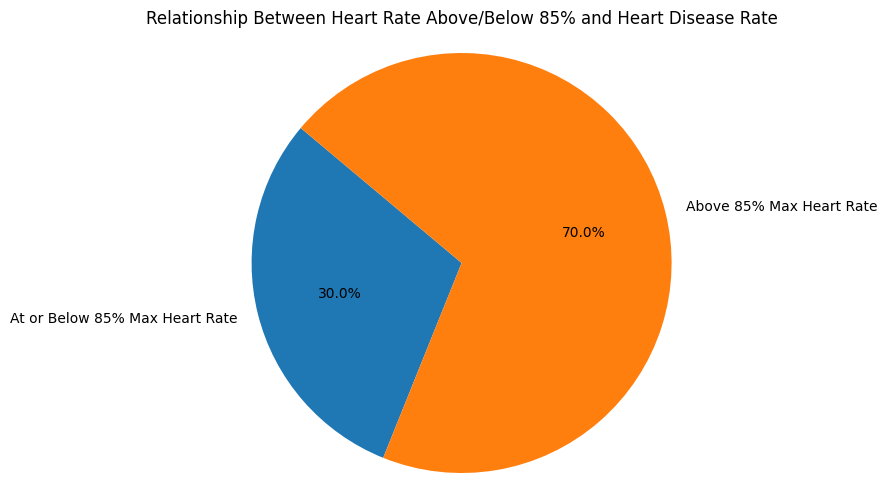

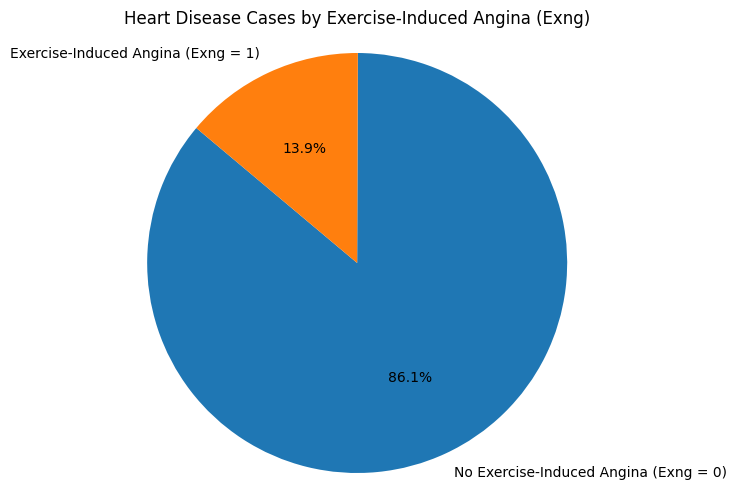

C:\Users\dell\AppData\Local\Temp\ipykernel_23460\3721793123.py:223: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heart_disease_rates = data.groupby('oldpeak_category')['output'].mean() * 100  # 将率转为百分比


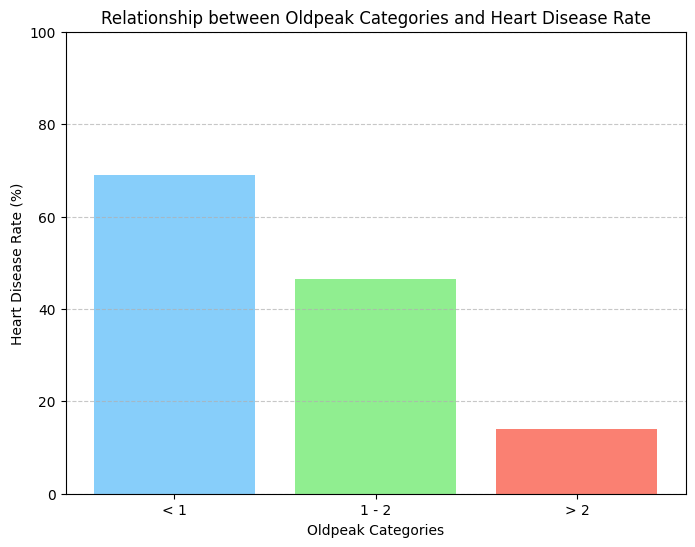

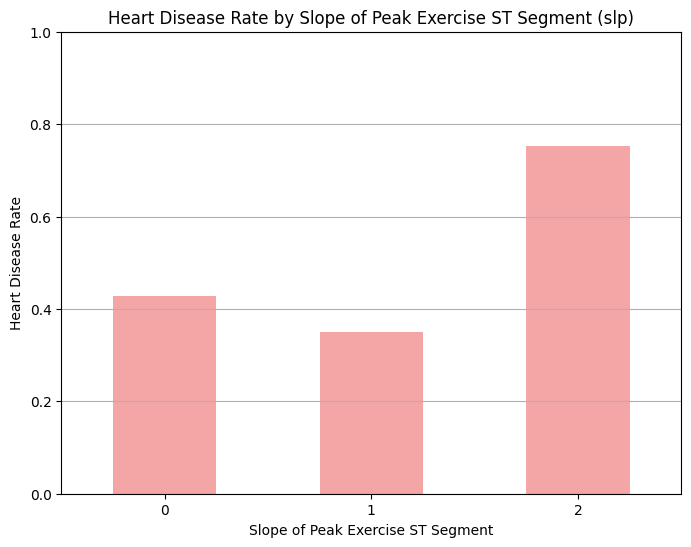

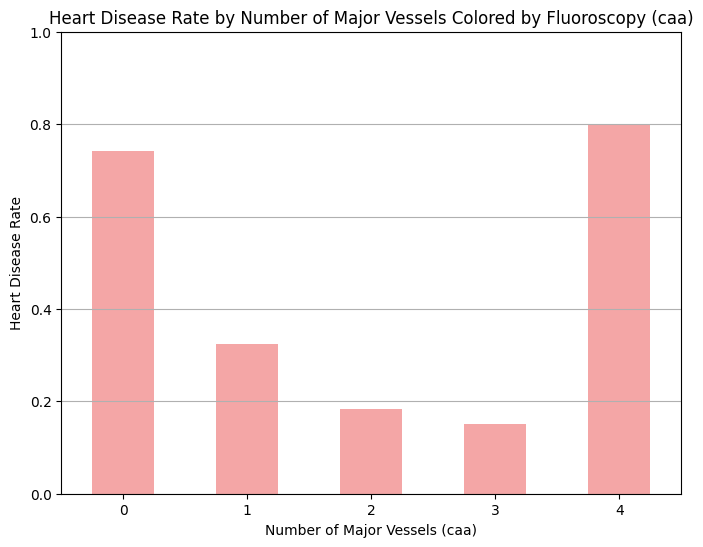

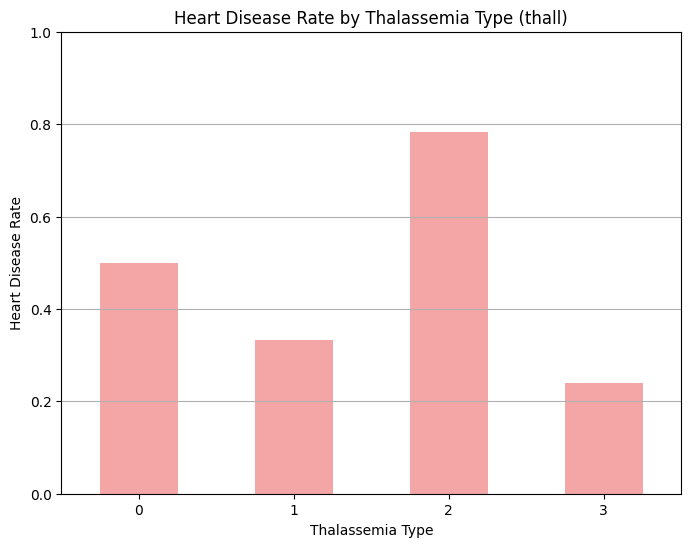

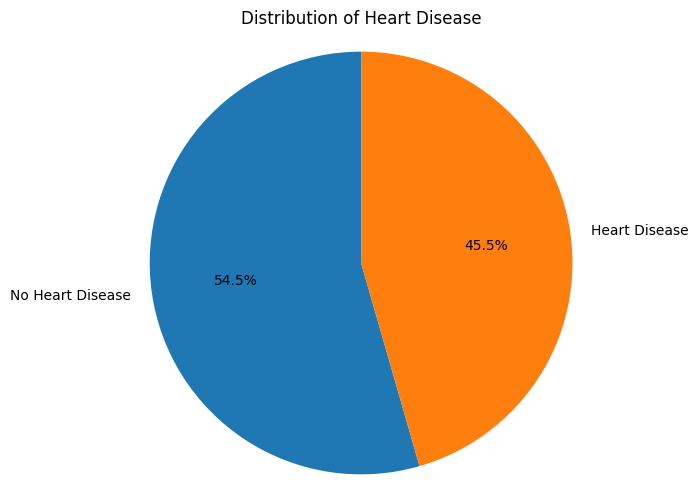

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据
data = pd.read_csv('heart.csv')

# 1. 绘制age分布条形图
plt.figure(figsize=(10, 6))
sns.histplot(data['age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

#绘制age在50以下和50以上与心脏病率的条形图
# 定义年龄组的条件和标签
data['age_group'] = pd.cut(data['age'], bins=[-1, 50, 100], labels=['< 50', '> 50'])

# 按年龄组统计心脏病的数量
age_counts = data.groupby('age_group')['output'].value_counts().unstack().fillna(0)

# 计算每个年龄组的心脏病率
age_counts['Heart Disease Rate'] = age_counts[1] / (age_counts[0] + age_counts[1])

# 绘制条形图
plt.figure(figsize=(8, 5))
age_counts['Heart Disease Rate'].plot(kind='bar', color='lightsalmon', alpha=0.7)

# 设置图表的细节
plt.title('Heart Disease Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Heart Disease Rate')
plt.xticks(rotation=0)  # X 轴标签旋转为0度
plt.ylim(0, 1)          # Y 轴范围从0到1
plt.grid(axis='y')

# 显示图表
plt.show()

# 2. 绘制sex与心脏病发生率的饼图
# 计算每个性别下的心脏病人数
heart_disease_counts = data.groupby(['sex', 'output']).size().unstack()

# 计算每个性别的心脏病百分比
heart_disease_percentage = heart_disease_counts.div(heart_disease_counts.sum(axis=1), axis=0) * 100

# 绘制饼图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['No Heart Disease', 'Heart Disease']
for ax, (sex, percentages) in zip(axes, heart_disease_percentage.iterrows()):
    ax.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=90)
    ax.axis('equal')  # 使饼图为圆形
    ax.set_title(f'Sex: {("Female" if sex == 0 else "Male")}')

plt.suptitle('Percentage of Heart Disease by Sex')
plt.tight_layout()
plt.show()

# 3. 绘制cp与心脏病发生率的条形图
# 计算每种胸痛类型下有和没有心脏病的数量
cp_counts = data.groupby(['cp', 'output']).size().unstack(fill_value=0)

# 计算每种胸痛类型的心脏病百分比
cp_percentage = cp_counts.div(cp_counts.sum(axis=1), axis=0) * 100

# 将数据转为 DataFrame 以便绘制
cp_percentage = cp_percentage.reset_index().melt(id_vars='cp', value_vars=[1],
                                                   var_name='output', value_name='percentage')
# 绘制条形图
plt.figure(figsize=(8, 5))
sns.barplot(x='cp', y='percentage', data=cp_percentage,color='red')

plt.title('Percentage of Heart Disease by Chest Pain Type')
plt.xlabel('Chest Pain Type (0-3)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)  # 横坐标标签不旋转
plt.tight_layout()
plt.show()

# 4. 绘制不同trtbps下心脏病率的bar diagram
# 创建静息血压分类
bins = [0, 130, 140, float('inf')]
labels = ['< 130', '130-140', '> 140']

# 计算每个类别心脏病患者数
bp_distribution['percentage'] = bp_distribution['output'] * 100

# 绘制条形图
plt.figure(figsize=(8, 6))
plt.bar(bp_distribution['bp_category'], bp_distribution['percentage'], color=['lightblue', 'lightgreen', 'salmon'])
plt.title('Heart Disease Percentage by Resting Blood Pressure Levels')
plt.xlabel('Resting Blood Pressure Levels (mm Hg)')
plt.ylabel('Heart Disease Percentage (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

# 5. 绘制每个胆固醇 (chol)水平下心脏病率bar diagram
# 创建胆固醇范围分类
bins = [0, 200, 240, float('inf')]
labels = ['< 200', '200-240', '> 240']

# 计算每个类别中心脏病患者的百分比
chol_distribution['percentage'] = chol_distribution['output'] * 100

# 绘制条形图
plt.figure(figsize=(8, 6))
plt.bar(chol_distribution['chol_category'], chol_distribution['percentage'], color=['lightblue', 'lightgreen', 'salmon'])
plt.title('Heart Disease Percentage by Cholesterol Levels')
plt.xlabel('Cholesterol Levels')
plt.ylabel('Heart Disease Percentage (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

# 6. 绘制空腹血糖 (fbs)水平下心脏病率pie diagram
# 计算不同空腹血糖类别下的心脏病案例数
# 'output' 列表示心脏病（1代表有心脏病，0代表没有心脏病）
blood_sugar_counts = data.groupby('fbs')['output'].value_counts().unstack(fill_value=0)

# 计算每个空腹血糖类别的心脏病比例
blood_sugar_counts['Heart Disease Cases'] = blood_sugar_counts[1]  # 心脏病病例
blood_sugar_counts['Total'] = blood_sugar_counts[0] + blood_sugar_counts[1]
blood_sugar_counts['Heart Disease %'] = (blood_sugar_counts['Heart Disease Cases'] / blood_sugar_counts['Total']) * 100

# 绘制饼图
labels = ['Fasting Blood Sugar < 120 mg/dl', 'Fasting Blood Sugar >= 120 mg/dl']
sizes = [blood_sugar_counts.loc[0, 'Heart Disease Cases'], blood_sugar_counts.loc[1, 'Heart Disease Cases']]
colors = ['lightcoral', 'lightskyblue']
explode = (0.1, 0)  # 突出显示第一个扇区

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)

# 设置图表的细节
plt.title('Heart Disease Cases by Fasting Blood Sugar Levels')
plt.axis('equal')  # 确保饼图是圆的
plt.show()

# 7. 绘制restecg与心脏病发生率的条形图
# 计算不同静息心电图结果类别下的心脏病案例数
# 假设 'restecg' 列表示静息心电图结果，0-2 表示三类
# 假设 'output' 列表示心脏病（1代表有心脏病，0代表没有心脏病）
ecg_counts = data.groupby('restecg')['output'].value_counts().unstack(fill_value=0)

# 计算每个静息心电图类别的心脏病病例数
ecg_counts['Heart Disease Cases'] = ecg_counts[1]  # 心脏病病例
ecg_counts['Total'] = ecg_counts[0] + ecg_counts[1]
ecg_counts['Heart Disease %'] = (ecg_counts['Heart Disease Cases'] / ecg_counts['Total']) * 100

# 绘制条形图
plt.figure(figsize=(10, 6))
bar_width = 0.4  # 条形宽度
x = range(len(ecg_counts))  # x轴位置

# 画心脏病病例的条形图
plt.bar(x, ecg_counts['Heart Disease %'], width=bar_width, color='coral', alpha=0.7)

# 设置图表的细节
plt.title('Heart Disease Percentage by Resting ECG Results')
plt.xlabel('Resting ECG Results')
plt.ylabel('Percentage of Heart Disease Cases (%)')
plt.xticks(x, ecg_counts.index)
plt.ylim(0, 100)  # 设置纵坐标范围为0到100%
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# 8. 绘制运动心率 (thalachh)水平下心脏病率
# Calculate heart disease rate
data['above_threshold'] = data['thalachh'] > (220 - data['age']) * 0.85

# Calculate heart disease rates
rates = data.groupby(data['above_threshold'])['output'].mean()

# Prepare data for pie chart
labels = ['Above 85% Max Heart Rate' if x else 'At or Below 85% Max Heart Rate' for x in rates.index]
sizes = rates.values

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Relationship Between Heart Rate Above/Below 85% and Heart Disease Rate')
plt.axis('equal')  # Makes the pie chart a circle
plt.show()

# 9. 绘制exng与心脏病率的饼图
# 计算不同运动引起的心绞痛类别下的心脏病案例数
# 假设 'exng' 列表示运动引起的心绞痛，0表示没有，1表示有
# 假设 'output' 列表示心脏病（1代表有心脏病，0代表没有心脏病）
exng_counts = data.groupby('exng')['output'].value_counts().unstack(fill_value=0)

# 计算每个运动引起的心绞痛类别的心脏病病例数
exng_counts['Heart Disease Cases'] = exng_counts[1]  # 心脏病病例
exng_counts['Total'] = exng_counts[0] + exng_counts[1]

# 提取心脏病病例数量
sizes = [exng_counts.loc[0, 'Heart Disease Cases'], exng_counts.loc[1, 'Heart Disease Cases']]
labels = ['No Exercise-Induced Angina (Exng = 0)', 'Exercise-Induced Angina (Exng = 1)']
colors = ['lightcoral', 'lightskyblue']
explode = (0.1, 0)  # 突出显示第一个扇区

# 绘制饼图
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)

# 设置图表的细节
plt.title('Heart Disease Cases by Exercise-Induced Angina (Exng)')
plt.axis('equal')  # 确保饼图是圆的
plt.show()

# 10. 绘制oldpeak与心脏病率的饼图
# 创建oldpeak区间
data['oldpeak_category'] = pd.cut(data['oldpeak'], bins=[-float('inf'), 1, 2, float('inf')],
                                   labels=['< 1', '1 - 2', '> 2'])

# 计算每个区间的心脏病率
heart_disease_rates = data.groupby('oldpeak_category')['output'].mean() * 100  # 将率转为百分比

# 准备绘图数据
labels = heart_disease_rates.index
rates = heart_disease_rates.values

# 绘制条形图
plt.figure(figsize=(8, 6))
plt.bar(labels, rates, color=['lightskyblue', 'lightgreen', 'salmon'])
plt.xlabel('Oldpeak Categories')
plt.ylabel('Heart Disease Rate (%)')
plt.title('Relationship between Oldpeak Categories and Heart Disease Rate')
plt.ylim(0, 100)  # 设置y轴范围为0到100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 11. slp与心脏病率的条形图
# 按 slp 分组并统计每个 slp 类别的心脏病案例数量
slp_counts = data.groupby('slp')['output'].value_counts().unstack().fillna(0)

# 计算每个 slp 类别的心脏病率
slp_counts['Heart Disease Rate'] = slp_counts[1] / (slp_counts[0] + slp_counts[1])

# 绘制条形图
plt.figure(figsize=(8, 6))
slp_counts['Heart Disease Rate'].plot(kind='bar', color='lightcoral', alpha=0.7)

# 设置图表的细节
plt.title('Heart Disease Rate by Slope of Peak Exercise ST Segment (slp)')
plt.xlabel('Slope of Peak Exercise ST Segment')
plt.ylabel('Heart Disease Rate')
plt.xticks(rotation=0)  # X轴标签旋转为0度
plt.ylim(0, 1)  # Y轴范围从0到1
plt.grid(axis='y')

# 显示图表
plt.show()

# 12. caa与心脏病率的条形图
# 按 caa 分组并统计每个 caa 类别中心脏病的数量
caa_counts = data.groupby('caa')['output'].value_counts().unstack().fillna(0)

# 计算每个 caa 类别的心脏病率
caa_counts['Heart Disease Rate'] = caa_counts[1] / (caa_counts[0] + caa_counts[1])

# 绘制条形图
plt.figure(figsize=(8, 6))
caa_counts['Heart Disease Rate'].plot(kind='bar', color='lightcoral', alpha=0.7)

# 设置图表的细节
plt.title('Heart Disease Rate by Number of Major Vessels Colored by Fluoroscopy (caa)')
plt.xlabel('Number of Major Vessels (caa)')
plt.ylabel('Heart Disease Rate')
plt.xticks(rotation=0)  # X轴标签旋转为0度
plt.ylim(0, 1)  # Y轴范围从0到1
plt.grid(axis='y')

# 显示图表
plt.show()

# 13. thall与心脏病率的条形图
import pandas as pd
import matplotlib.pyplot as plt

# 假设 data 是您的数据集
# data = pd.read_csv('heart.csv')

# 按 thall分组并统计每个 thall 类别的心脏病数量
thall_counts = data.groupby('thall')['output'].value_counts().unstack().fillna(0)

# 计算每个 thal 类别的心脏病率
thall_counts['Heart Disease Rate'] = thall_counts[1] / (thall_counts[0] + thall_counts[1])

# 绘制条形图
plt.figure(figsize=(8, 6))
thall_counts['Heart Disease Rate'].plot(kind='bar', color='lightcoral', alpha=0.7)

# 设置图表的细节
plt.title('Heart Disease Rate by Thalassemia Type (thall)')
plt.xlabel('Thalassemia Type')
plt.ylabel('Heart Disease Rate')
plt.xticks(rotation=0)  # X轴标签旋转为0度
plt.ylim(0, 1)          # Y轴范围从0到1
plt.grid(axis='y')

# 显示图表
plt.show()

# 14. 绘制心脏病发生率的饼图
output_counts = data['output'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(output_counts, labels=['No Heart Disease', 'Heart Disease'], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Heart Disease')
plt.axis('equal')  # 把饼图设置为圆形
plt.show()

Task2: Apply multiple ML tools (at least 4) to classify heart disease
Task3: Analyze the computation efficiency (e.g., in running time) and accuracy

In [49]:
import pandas as pd
import time  # 导入 time 模块
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 读取数据
df = pd.read_csv('heart.csv')

# 特征和标签
X = df.drop('output', axis=1)
y = df['output']

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 定义分类器
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(),
    'Decision Tree': DecisionTreeClassifier()
}

# 训练并评估分类器
results = {}
for name, clf in classifiers.items():
    # 记录训练开始时间
    start_time = time.time()

    # 训练分类器
    clf.fit(X_train, y_train)

    # 预测
    predictions = clf.predict(X_test)

    # 计算准确率
    accuracy = accuracy_score(y_test, predictions)

    # 记录结束时间
    end_time = time.time()

    # 计算运行时间
    run_time = end_time - start_time

    results[name] = {'Accuracy': accuracy, 'Run Time': run_time}

# 打印结果
for name, metrics in results.items():
    print(f'{name}:')
    print(f'  Accuracy: {metrics["Accuracy"]:.2f}')
    print(f'  Run Time: {metrics["Run Time"]:.4f} seconds\n')

Logistic Regression:
  Accuracy: 0.89
  Run Time: 0.0614 seconds

Random Forest:
  Accuracy: 0.85
  Run Time: 0.1097 seconds

Support Vector Machine:
  Accuracy: 0.70
  Run Time: 0.0040 seconds

Decision Tree:
  Accuracy: 0.77
  Run Time: 0.0030 seconds



Task4: Visualize the importance of each feature for classification by SHAP

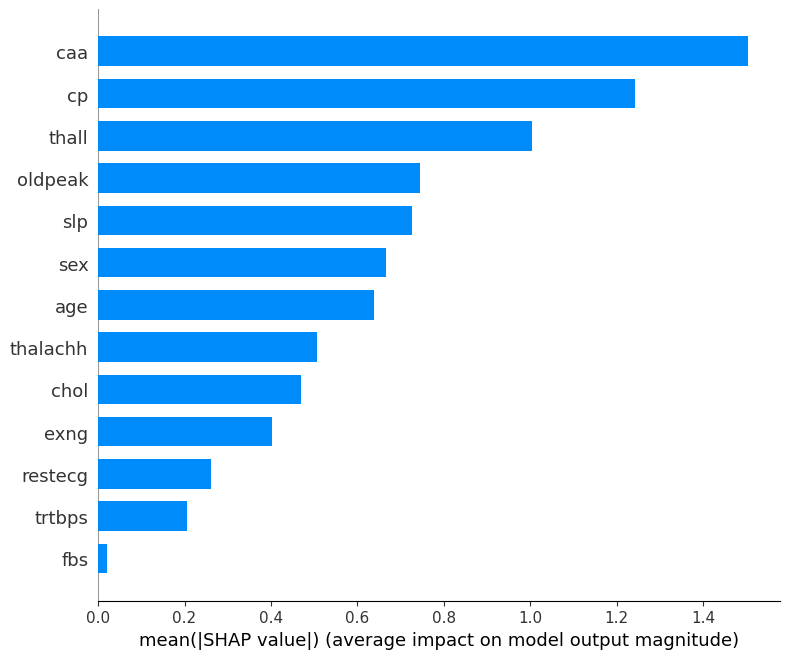

In [50]:
import pandas as pd
import xgboost as xgb #install xgboost-cpu
import shap
import matplotlib.pyplot as plt

# 读取数据集
data = pd.read_csv('heart.csv')

# 分离特征和目标变量
X = data[['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall']]
y = data['output']

# 训练 XGBoost 模型
model = xgb.XGBClassifier(eval_metric='logloss')
model.fit(X, y)

# 创建 SHAP 值并可视化特征重要性
shap_values = shap.Explainer(model).shap_values(X)

# 可视化特征重要性
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type="bar", feature_names=X.columns)
plt.show()